In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Indian_Budget_Analysis")

In [4]:
df['metric_type'] = df['metric_type'].str.lower()
df.iloc[:55]

,Category,Actual,Budgeted,Revised,Next_Budget,Change,Year,metric_type,group
0,Revenue Expenditure,2350604.0,2630145.0,3011142.0,2929000.0,12.0,2021-22,amount,Expenditure
1,Capital Expenditure,335726.0,412085.0,439163.0,554236.0,29.0,2021-22,amount,Expenditure
2,Capital Outlay,311312.0,380322.0,332247.0,513862.0,29.0,2021-22,amount,Expenditure
3,Loans and Advances,24414.0,31763.0,106916.0,40374.0,29.0,2021-22,amount,Expenditure
4,Total Expenditure,2686330.0,3042230.0,3450305.0,3483236.0,14.0,2021-22,amount,Expenditure
5,Revenue Receipts,1684059.0,2020926.0,1555153.0,1788424.0,3.0,2021-22,amount,Receipts
6,Capital Receipts,68620.0,224967.0,46497.0,188000.0,66.0,2021-22,amount,Receipts
7,Recoveries of Loans and Advances,18316.0,14967.0,14497.0,13000.0,-16.0,2021-22,amount,Receipts
8,Other receipts (including disinvestments),50304.0,210000.0,32000.0,175000.0,87.0,2021-22,amount,Receipts
9,Total Receipts (excluding borrowings),1752679.0,2245893.0,1601650.0,1976424.0,6.0,2021-22,amount,Receipts


In [5]:
print(df.shape)
print(df.columns)
print(df.info())


(96, 9)
Index(['Category', 'Actual', 'Budgeted', 'Revised', 'Next_Budget', 'Change',
       'Year', 'metric_type', 'group'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Category     96 non-null     str    
 1   Actual       96 non-null     float64
 2   Budgeted     96 non-null     float64
 3   Revised      96 non-null     float64
 4   Next_Budget  96 non-null     float64
 5   Change       79 non-null     float64
 6   Year         96 non-null     str    
 7   metric_type  96 non-null     str    
 8   group        96 non-null     str    
dtypes: float64(5), str(4)
memory usage: 6.9 KB
None


<center><h1>Storing The Data into Database</h1></center>

In [6]:
from sqlalchemy import create_engine, text


user     = "root"
password = "admin"
host     = "localhost"
port     = "3306"
database = "india_budget"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
)


# Load CSV
df = pd.read_csv('Indian_Budget_Analysis')


# Fix casing
df['metric_type'] = df['metric_type'].str.lower()
df['group']       = df['group'].str.lower()


#Change the year Column value
df['Year'] = df['Year'].replace({
    '2021-22': '2021',
    '2022-23': '2022',
    '2023-24': '2023',
    '2024-25': '2024',
    '2025-26': '2025',
    '2026-27': '2026'
})

df['Year'] = df['Year'].astype(int)




# Reset index starting from 1
df = df.reset_index(drop=True)
df.index = df.index + 1

# Split
df_values = df[df['metric_type'] == 'amount'].copy().reset_index(drop=True)
df_gdp    = df[df['metric_type'] == 'gdp_ratio'].copy().reset_index(drop=True)

# ── Use all lowercase table names ✅
df.to_sql('5_years_budget', engine, if_exists='replace', index=True, index_label='id')
df_values.to_sql('budget_values', engine, if_exists='replace', index=True, index_label='id')
df_gdp.to_sql('budget_gdp_ratios', engine, if_exists='replace', index=True, index_label='id')

print("✅ Data stored successfully!")

# Verify
with engine.connect() as conn:
    r1 = conn.execute(text("SELECT COUNT(*) FROM 5_years_budget"))
    print("5_years_budget rows:    ", r1.fetchone()[0])

    r2 = conn.execute(text("SELECT COUNT(*) FROM budget_values"))
    print("budget_values rows:     ", r2.fetchone()[0])

    r3 = conn.execute(text("SELECT COUNT(*) FROM budget_gdp_ratios"))
    print("budget_gdp_ratios rows: ", r3.fetchone()[0])



✅ Data stored successfully!
5_years_budget rows:     96
budget_values rows:      78
budget_gdp_ratios rows:  18


In [7]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = result.fetchall()
    print("Tables in india_budget database:")
    for table in tables:
        print(" -", table[0])
        

Tables in india_budget database:
 - 5_years_budget
 - budget_gdp_ratios
 - budget_values


<center><h1>Prediction Stage</h1></center>



In [8]:
import pandas as pd

# Load data
df = pd.read_csv("Indian_Budget_Analysis")

df['Year'] = df['Year'].replace({
    '2021-22': '2021',
    '2022-23': '2022',
    '2023-24': '2023',
    '2024-25': '2024',
    '2025-26': '2025',
    '2026-27': '2026'
})


# Filter for one category
cat_df = df[
    (df['Category'] == 'Total Expenditure') &
    (df['metric_type'] == 'Amount')
][['Year', 'Actual']].sort_values('Year')

cat_df

,Year,Actual
4,2021,2686330.0
20,2022,3509836.0
36,2023,3793801.0
52,2024,4193157.0
68,2025,4443447.0
84,2026,4652867.0


In [9]:
# Convert year to integer
cat_df['Year'] = cat_df['Year'].astype(int)

X = cat_df['Year'].values.reshape(-1, 1)
y = cat_df['Actual'].values

cat_df.dtypes

Year        int64
Actual    float64
dtype: object

<center><h2>Linear Regression For Expenditure</h2></center>

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
pred_2027 = model.predict(poly.transform([[2027]]))[0]

print(f"Predicted Total Expenditure for 2027: ₹{pred_2027:,.0f} Crore")

Predicted Total Expenditure for 2027: ₹4,649,005 Crore


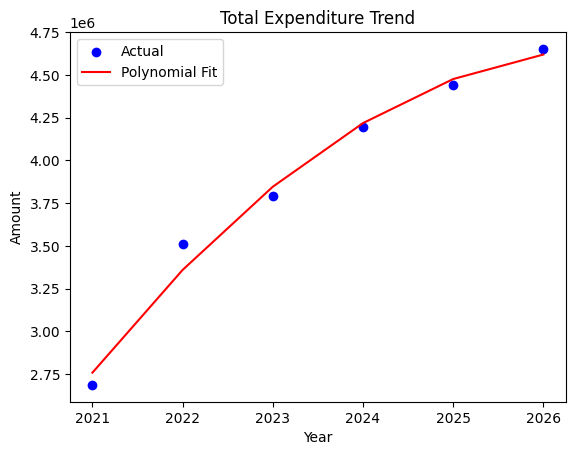

In [12]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_poly)

plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Polynomial Fit')

plt.title("Total Expenditure Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()

plt.show()

In [13]:
from sklearn.metrics import r2_score

print("R2:", r2_score(y, y_pred))

R2: 0.9870823522139092


In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load your data
df = pd.read_csv("Indian_Budget_Analysis")

df['Year'] = df['Year'].replace({
    '2021-22': '2021',
    '2022-23': '2022',
    '2023-24': '2023',
    '2024-25': '2024',
    '2025-26': '2025',
    '2026-27': '2026'
})

# Filter only 'amount' type (important)
df = df[df['metric_type'] == 'Amount']

# Store predictions
predictions = []

# Loop through each category
for category in df['Category'].unique():
    
    cat_df = df[df['Category'] == category].sort_values('Year')
    
    # Features and target
    X = cat_df[['Year']]
    y = cat_df['Actual']
    
    # Train model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict for 2027
    pred_2027 = model.predict([[2027]])[0]
    
    predictions.append({
        "Category": category,
        "Predicted_2027": round(pred_2027, 2)
    })

# Convert to DataFrame
pred_df = pd.DataFrame(predictions)

print(pred_df)

                                     Category  Predicted_2027
0                         Revenue Expenditure      3970820.00
1                         Capital Expenditure      1212373.67
2                              Capital Outlay       994297.00
3                          Loans and Advances       218077.40
4                           Total Expenditure      5183193.73
5                            Revenue Receipts      3298935.73
6                            Capital Receipts        47091.00
7            Recoveries of Loans and Advances        28735.67
8   Other receipts (including disinvestments)        18355.87
9       Total Receipts (excluding borrowings)      3346026.07
10                            Revenue Deficit       671884.93
11                             Fiscal Deficit      1837167.67
12                            Primary Deficit       590345.47


C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\util

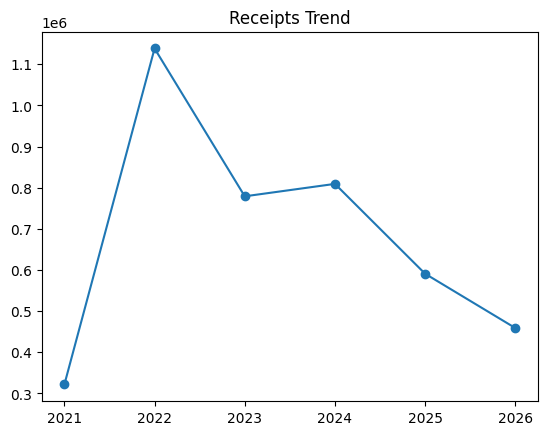

In [15]:
plt.plot(cat_df['Year'], cat_df['Actual'], marker='o')
plt.title("Receipts Trend")
plt.show()

In [18]:
growth = cat_df['Actual'].pct_change().mean()

last_value = cat_df['Actual'].iloc[-1]

pred_2027 = last_value * (1 + growth)

print(pred_2027)

621282.4182079763


<center><h2>Prophet Model for Expenditure, Receipts and Deficit</h2></center>

In [ ]:
pip install prophet

C:\Users\Rudraksh\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
00:01:21 - cmdstanpy - INFO - Chain [1] start processing


       PROPHET - BUDGET PREDICTION 2027


00:01:21 - cmdstanpy - INFO - Chain [1] done processing



Forecast years available: [2021, 2022, 2023, 2024, 2025, 2026, 2027]

── Expenditure ──
R² Score       : 0.9629
MAE            : ₹106,642 Crore
Predicted 2027 : ₹5,241,164 Crore
Confidence     : ₹4,999,047 – ₹5,483,286 Crore


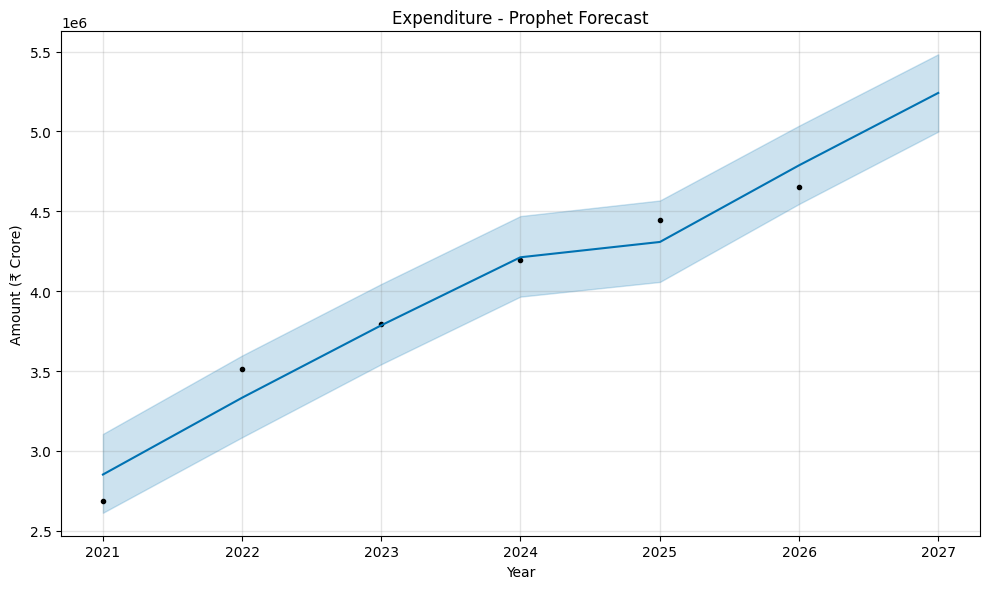

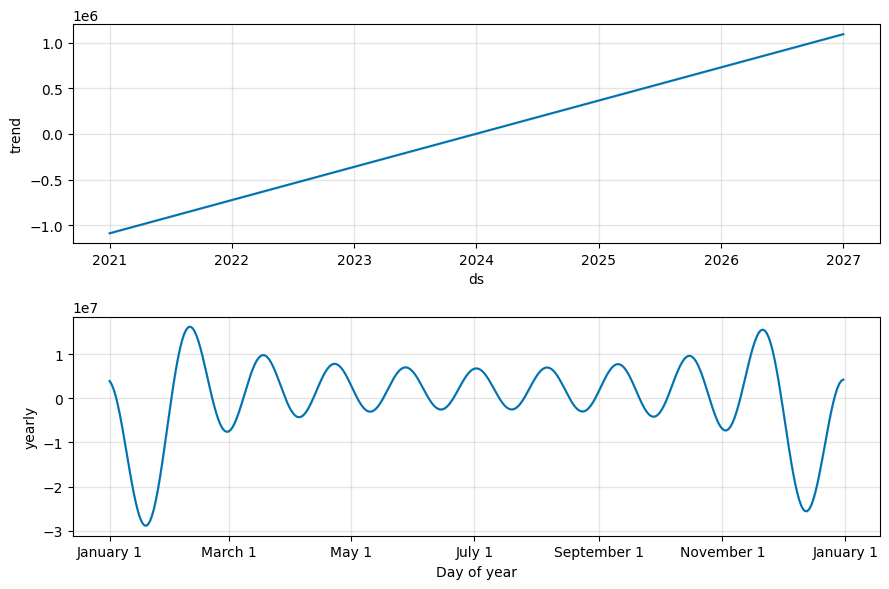

00:01:21 - cmdstanpy - INFO - Chain [1] start processing
00:01:21 - cmdstanpy - INFO - Chain [1] done processing



Forecast years available: [2021, 2022, 2023, 2024, 2025, 2026, 2027]

── Receipts ──
R² Score       : 0.9664
MAE            : ₹70,892 Crore
Predicted 2027 : ₹3,320,333 Crore
Confidence     : ₹3,139,262 – ₹3,481,711 Crore


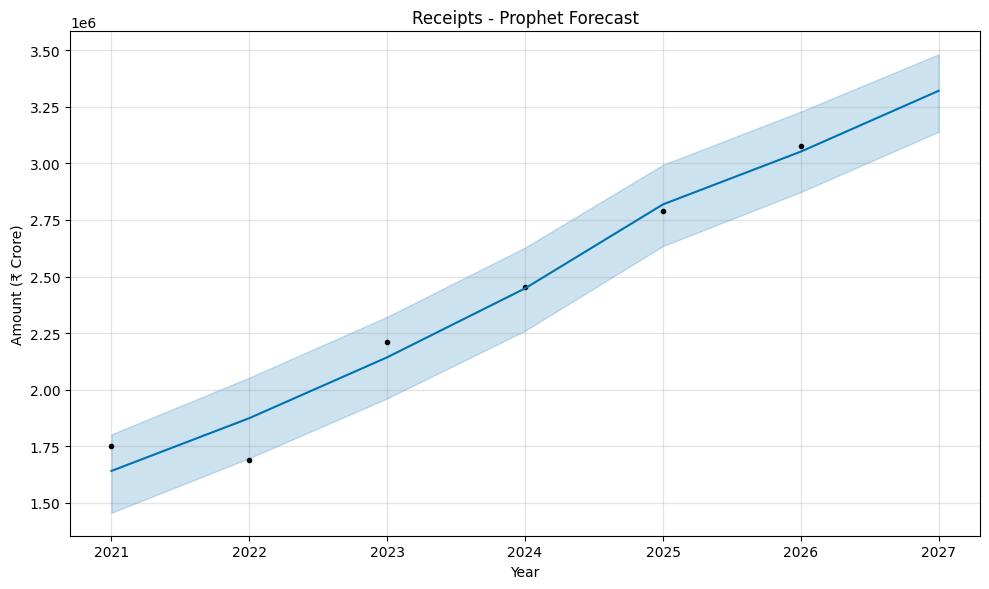

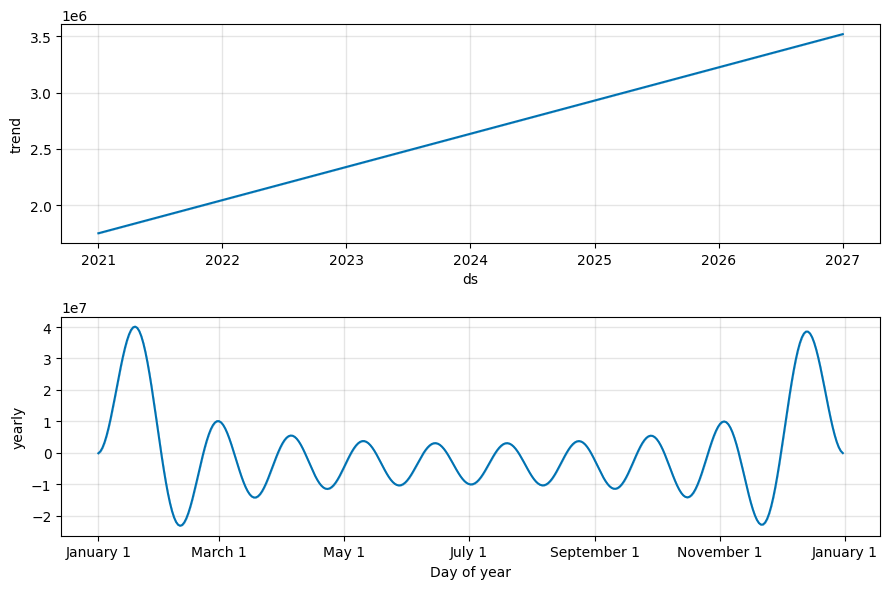

00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing



Forecast years available: [2021, 2022, 2023, 2024, 2025, 2026, 2027]

── Deficit ──
R² Score       : 0.4310
MAE            : ₹176,629 Crore
Predicted 2027 : ₹1,902,808 Crore
Confidence     : ₹1,481,887 – ₹2,328,128 Crore


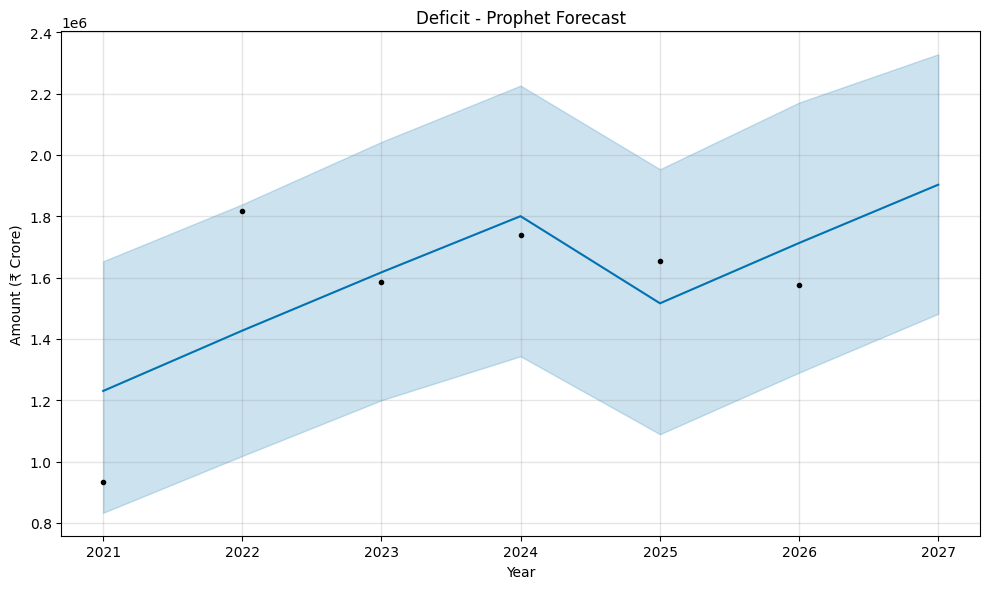

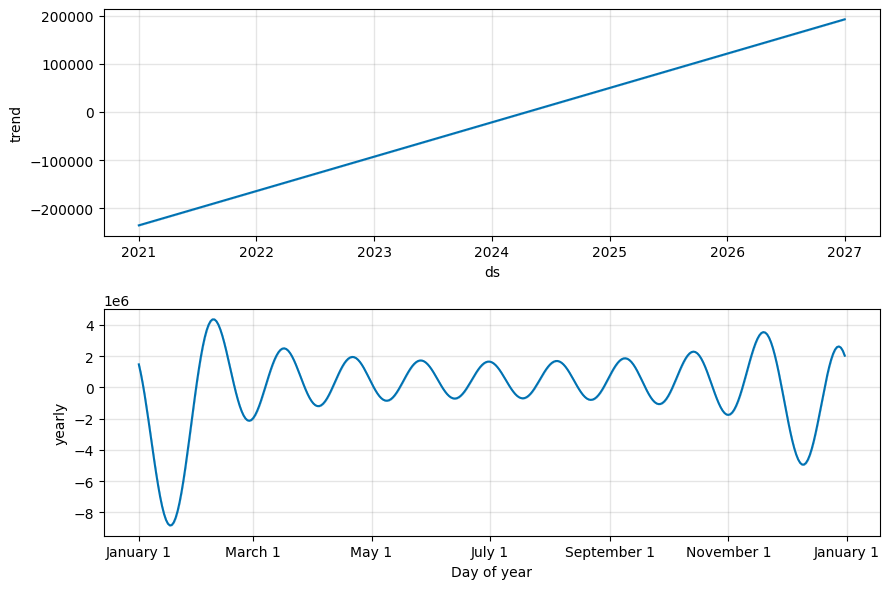


SUMMARY
Expenditure     → ₹5,241,164 Crore in 2027
                   Range: ₹4,999,047 – ₹5,483,286 Crore
Receipts        → ₹3,320,333 Crore in 2027
                   Range: ₹3,139,262 – ₹3,481,711 Crore
Deficit         → ₹1,902,808 Crore in 2027
                   Range: ₹1,481,887 – ₹2,328,128 Crore


In [19]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ── Load data
df = pd.read_csv("Indian_Budget_Analysis")

# ── Categories to predict
categories = {
    'Total Expenditure': 'Expenditure',
    'Total Receipts (excluding borrowings)': 'Receipts',
    'Fiscal Deficit': 'Deficit'
}

# ── Fix Year column
df['Year'] = df['Year'].replace({
    '2021-22': '2021',
    '2022-23': '2022',
    '2023-24': '2023',
    '2024-25': '2024',
    '2025-26': '2025',
    '2026-27': '2026'
})
df['Year'] = df['Year'].astype(int)

results = {}
print("=" * 60)
print("       PROPHET - BUDGET PREDICTION 2027")
print("=" * 60)

for category, label in categories.items():

    # ── Filter data
    cat_df = df[
        (df['Category'] == category) &
        (df['metric_type'] == 'Amount')
    ][['Year', 'Actual']].dropna().sort_values('Year')

    if cat_df.empty:
        print(f"\n⚠ No data for {label}")
        continue

    # ── Prophet requires columns named 'ds' and 'y'
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(cat_df['Year'], format='%Y'),
        'y': cat_df['Actual'].values
    })

    # ── Initialize and Train Prophet Model
    model = Prophet(
        yearly_seasonality=True,
        interval_width=0.95,
        changepoint_prior_scale=0.1,
        seasonality_mode='additive'
    )
    model.fit(prophet_df)

    # ── Manually create future dataframe including 2027 (FIXED)
    last_date = prophet_df['ds'].max()
    future_dates = pd.date_range(
        start=prophet_df['ds'].min(),
        periods=len(prophet_df) + 1,   # +1 to include 2027
        freq='YS'                       # YS = Year Start (more reliable)
    )
    future = pd.DataFrame({'ds': future_dates})

    # ── Predict
    forecast = model.predict(future)

    # ── Debug: print available years in forecast
    print(f"\nForecast years available: {forecast['ds'].dt.year.tolist()}")

    # ── Extract 2027 prediction (FIXED)
    pred_row = forecast[forecast['ds'].dt.year == 2027]
    if pred_row.empty:
        # fallback: take the last row as 2027 prediction
        pred_row = forecast.iloc[[-1]]

    pred_2027 = pred_row['yhat'].values[0]
    lower     = pred_row['yhat_lower'].values[0]
    upper     = pred_row['yhat_upper'].values[0]

    # ── Metrics on historical data
    historical = forecast.iloc[:-1]   # all rows except last (2027)
    r2  = r2_score(prophet_df['y'], historical['yhat'])
    mae = mean_absolute_error(prophet_df['y'], historical['yhat'])

    results[label] = {
        'predicted': round(pred_2027, 0),
        'lower':     round(lower, 0),
        'upper':     round(upper, 0),
        'r2':        round(r2, 4),
        'mae':       round(mae, 0)
    }

    print(f"\n── {label} ──")
    print(f"R² Score       : {r2:.4f}")
    print(f"MAE            : ₹{mae:,.0f} Crore")
    print(f"Predicted 2027 : ₹{pred_2027:,.0f} Crore")
    print(f"Confidence     : ₹{lower:,.0f} – ₹{upper:,.0f} Crore")

    # ── Plot 1: Prophet built-in forecast plot
    fig1 = model.plot(forecast)
    plt.title(f"{label} - Prophet Forecast")
    plt.xlabel("Year")
    plt.ylabel("Amount (₹ Crore)")
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Components
    fig2 = model.plot_components(forecast)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for label, data in results.items():
    print(f"{label:15} → ₹{data['predicted']:,.0f} Crore in 2027")
    print(f"{'':15}    Range: ₹{data['lower']:,.0f} – ₹{data['upper']:,.0f} Crore")

   BUDGET PREDICTION 2027 — LINEAR REGRESSION

── Total Expenditure ──
  Predicted 2027 : ₹      5,183,194 Crore
  R² Score       : 0.9397   🟡 Good
  MAE            : ₹        140,205 Crore
  RMSE           : ₹        161,065 Crore
  MAPE           : 4.05%
  Accuracy       : 95.95%


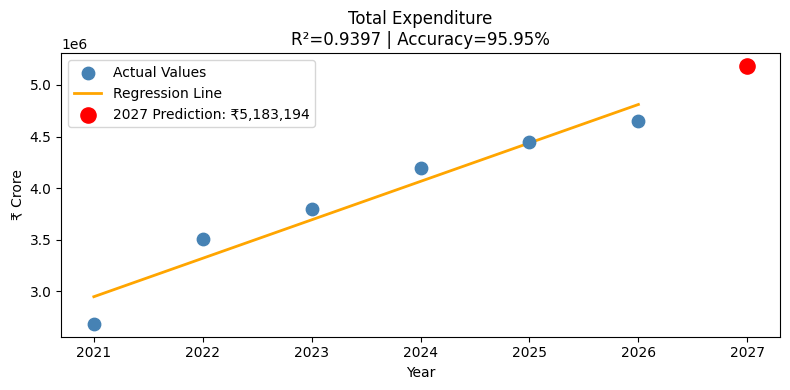


── Total Receipts ──
  Predicted 2027 : ₹      3,346,026 Crore
  R² Score       : 0.9577   🟢 Excellent
  MAE            : ₹         73,764 Crore
  RMSE           : ₹        104,312 Crore
  MAPE           : 4.00%
  Accuracy       : 96.00%


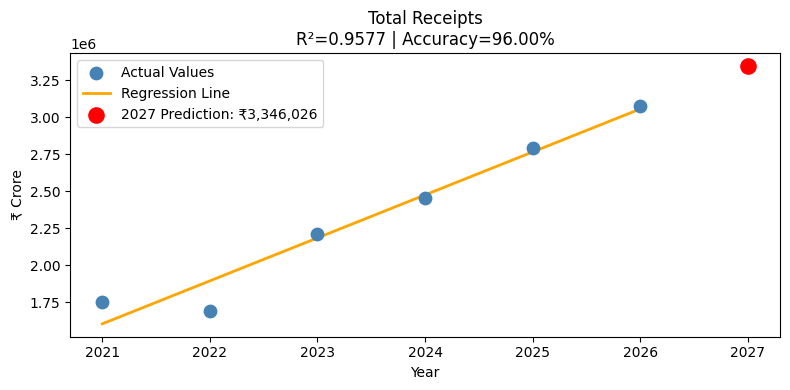


── Total Deficit ──
  Predicted 2027 : ₹      1,837,168 Crore
  R² Score       : 0.2348   🔴 Poor
  MAE            : ₹        203,919 Crore
  RMSE           : ₹        252,487 Crore
  MAPE           : 15.23%
  Accuracy       : 84.77%


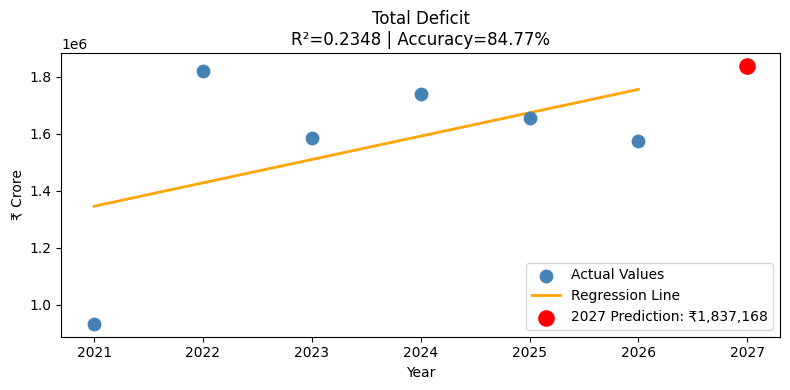


FINAL SUMMARY

  Total Expenditure
  ────────────────────────────────────────
  Predicted 2027 : ₹      5,183,194 Crore
  R² Score       : 0.9397
  Accuracy       : 95.95%
  Reliability    : 🟡 Good

  Total Receipts
  ────────────────────────────────────────
  Predicted 2027 : ₹      3,346,026 Crore
  R² Score       : 0.9577
  Accuracy       : 96.0%
  Reliability    : 🟢 Excellent

  Total Deficit
  ────────────────────────────────────────
  Predicted 2027 : ₹      1,837,168 Crore
  R² Score       : 0.2348
  Accuracy       : 84.77%
  Reliability    : 🔴 Poor

✅ Saved to 3_Category_Predictions_2027.csv


In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Load data
df = pd.read_csv("Indian_Budget_Analysis")

# ── Fix Year column
df['Year'] = df['Year'].replace({
    '2021-22': '2021',
    '2022-23': '2022',
    '2023-24': '2023',
    '2024-25': '2024',
    '2025-26': '2025',
    '2026-27': '2026'
})
df['Year'] = df['Year'].astype(int)

# ── ONLY 3 Categories
categories = {
    'Total Expenditure'                    : 'Total Expenditure',
    'Total Receipts (excluding borrowings)': 'Total Receipts',
    'Fiscal Deficit'                       : 'Total Deficit'
}

results = []

print("=" * 60)
print("   BUDGET PREDICTION 2027 — LINEAR REGRESSION")
print("=" * 60)

for category, label in categories.items():

    # ── Filter
    cat_df = df[
        (df['Category'] == category) &
        (df['metric_type'] == 'Amount')
    ][['Year', 'Actual']].dropna().sort_values('Year')

    if cat_df.empty:
        print(f"\n⚠ No data for {label}")
        continue

    X = cat_df['Year'].values.reshape(-1, 1)
    y = cat_df['Actual'].values

    # ── Train
    model = LinearRegression()
    model.fit(X, y)

    # ── Predict on historical
    y_pred = model.predict(X)

    # ── Metrics
    r2       = r2_score(y, y_pred)
    mae      = mean_absolute_error(y, y_pred)
    rmse     = np.sqrt(mean_squared_error(y, y_pred))
    mape     = np.mean(np.abs((y - y_pred) / y)) * 100
    accuracy = 100 - mape

    # ── Predict 2027
    pred_2027 = model.predict([[2027]])[0]

    # ── Reliability
    if r2 >= 0.95:
        reliability = '🟢 Excellent'
    elif r2 >= 0.85:
        reliability = '🟡 Good'
    elif r2 >= 0.70:
        reliability = '🟠 Moderate'
    else:
        reliability = '🔴 Poor'

    results.append({
        'Category'      : label,
        'Predicted_2027': round(pred_2027, 0),
        'R2_Score'      : round(r2, 4),
        'MAE'           : round(mae, 0),
        'RMSE'          : round(rmse, 0),
        'MAPE_%'        : round(mape, 2),
        'Accuracy_%'    : round(accuracy, 2),
        'Reliability'   : reliability
    })

    # ── Print
    print(f"\n── {label} ──")
    print(f"  Predicted 2027 : ₹{pred_2027:>15,.0f} Crore")
    print(f"  R² Score       : {r2:.4f}   {reliability}")
    print(f"  MAE            : ₹{mae:>15,.0f} Crore")
    print(f"  RMSE           : ₹{rmse:>15,.0f} Crore")
    print(f"  MAPE           : {mape:.2f}%")
    print(f"  Accuracy       : {accuracy:.2f}%")

    # ── Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(X, y, color='steelblue', s=80,
                label='Actual Values', zorder=5)
    plt.plot(X, y_pred, color='orange',
             linewidth=2, label='Regression Line')
    plt.scatter([[2027]], [[pred_2027]],
                color='red', s=120, zorder=6,
                label=f'2027 Prediction: ₹{pred_2027:,.0f}')
    plt.title(f"{label}\nR²={r2:.4f} | Accuracy={accuracy:.2f}%")
    plt.xlabel("Year")
    plt.ylabel("₹ Crore")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── Final Summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
for r in results:
    print(f"\n  {r['Category']}")
    print(f"  {'─'*40}")
    print(f"  Predicted 2027 : ₹{r['Predicted_2027']:>15,.0f} Crore")
    print(f"  R² Score       : {r['R2_Score']}")
    print(f"  Accuracy       : {r['Accuracy_%']}%")
    print(f"  Reliability    : {r['Reliability']}")

# ── Save
results_df = pd.DataFrame(results)
results_df.to_csv("3_Category_Predictions_2027.csv", index=False)
print("\n✅ Saved to 3_Category_Predictions_2027.csv")